# Final Project MLOps: Pseudo-Labeling and Feature Engineering (CP1)

Greycia Febrina Michelle & Aulia Aca Azzahra, SISTECH 2026

Revision 2. The core query function, the severity table, and the temporal decay calibration are unchanged from the first version and already verified against the mentor feedback from Hands-On 1. This revision fixes three things raised after the first version went out: the point-query scorer and the training table were calibrated against two slightly different normalization ceilings, the query function had no defined behavior for timezone-aware timestamps once the FE team confirmed they would send them, and the risk level categories needed to move from three tiers to four to match the badge system FE is building.

What changed for the final project, from the original Hands-On work: Hands-On 1 and 2 produced a static table, one row per combination of grid cell, day of week, and hour that had at least one historical crime. The final project needs a function that can answer a query for any coordinate and any timestamp, including locations that never had a recorded crime nearby. A static table cannot represent that case at all, so part of this notebook is an architecture change, not just a parameter change.

What the mentor flagged on Hands-On 1: the hour 0 spike in the data was documented as a likely data quality artifact but never actually handled in the pipeline, and the hotspot comparison between the crime density map and the risk score map was visual only, never tested with a real correlation number. Both are addressed here with actual computation.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

PRIMARY = "#A1007E"
ACCENT = "#D6008C"
TITLE_CLR = "#2A2882"

plt.rcParams["axes.titlecolor"] = TITLE_CLR

print("Setup complete")


Setup complete


## Loading the Event-Level Dataset

`events_scored.csv` is the per-event dataset produced during Hands-On 1, before it gets collapsed into the grid summary table. It still has the original timestamp for every crime, together with the severity score already computed for it. This is the file the rest of this notebook works from, not the aggregated `features_labels.csv`.


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/SISTECH/events_scored.csv"
events = pd.read_csv(DATA_PATH, parse_dates=["Datetime"])

print(f"Rows: {len(events):,}")
print(f"Date range: {events['Datetime'].min()} to {events['Datetime'].max()}")
events.head(3)


Rows: 550,896
Date range: 2024-01-01 00:00:00 to 2026-04-11 00:00:00


,Datetime,cell_id,lat_r,lon_r,dow,hour,Primary Type,Description,severity,age_days,w_time,event_value
0,2026-04-11,41.8_-87.65,41.80,-87.65,5,0,THEFT,$500 AND UNDER,16.0,0.0,1.0,16.0
1,2026-04-11,41.88_-87.68,41.88,-87.68,5,0,BATTERY,SIMPLE,38.0,0.0,1.0,38.0
2,2026-04-11,41.98_-87.7,41.98,-87.70,5,0,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,18.0,0.0,1.0,18.0


## From a Static Table to a Query Function

Hands-On 1 built `unit`, a table grouped by cell, day of week, and hour, then computed one risk score per row. That works for training a model later, but it cannot answer "what is the risk at this exact coordinate right now" unless that exact coordinate already happens to be a cell with recorded history.

The final project's example table makes this gap concrete. One of the four rows is "no crime within radius, risk score equals zero exactly." A groupby table never produces that row, because groupby only ever returns combinations that already exist in the data.

The fix here is to rewrite severity, decay, and spatial weighting as a function that takes a coordinate and a timestamp directly, searches nearby historical events at call time, and returns zero cleanly when nothing relevant is found nearby. The severity table itself is unchanged from Hands-On 1 and 2, it is reused as is below.


In [4]:
SEVERITY_DEFAULT_BY_TYPE = {
    "HOMICIDE": 100, "CRIMINAL SEXUAL ASSAULT": 92, "SEX OFFENSE": 60,
    "KIDNAPPING": 88, "HUMAN TRAFFICKING": 88, "OFFENSE INVOLVING CHILDREN": 70,
    "ROBBERY": 68, "ARSON": 65, "ASSAULT": 50, "BATTERY": 45,
    "STALKING": 45, "WEAPONS VIOLATION": 45, "INTIMIDATION": 40, "BURGLARY": 40,
    "MOTOR VEHICLE THEFT": 32, "THEFT": 28, "NARCOTICS": 22, "OTHER NARCOTIC VIOLATION": 20,
    "CRIMINAL DAMAGE": 18, "DECEPTIVE PRACTICE": 18, "CRIMINAL TRESPASS": 14,
    "OTHER OFFENSE": 14, "PROSTITUTION": 12, "PUBLIC PEACE VIOLATION": 12,
    "PUBLIC INDECENCY": 12, "OBSCENITY": 15, "INTERFERENCE WITH PUBLIC OFFICER": 25,
    "GAMBLING": 6, "LIQUOR LAW VIOLATION": 6, "CONCEALED CARRY LICENSE VIOLATION": 8,
    "NON-CRIMINAL": 5,
}

SEVERITY_OVERRIDE = {
    ("BATTERY", "DOMESTIC BATTERY SIMPLE"): 42,
    ("BATTERY", "SIMPLE"): 38,
    ("BATTERY", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 75,
    ("BATTERY", "AGGRAVATED - HANDGUN"): 85,
    ("THEFT", "$500 AND UNDER"): 16,
    ("THEFT", "OVER $500"): 30,
    ("THEFT", "RETAIL THEFT"): 12,
    ("THEFT", "FROM BUILDING"): 25,
    ("THEFT", "THEFT FROM MOTOR VEHICLE"): 22,
    ("THEFT", "FROM PERSON"): 40,
    ("CRIMINAL DAMAGE", "TO VEHICLE"): 14,
    ("CRIMINAL DAMAGE", "TO PROPERTY"): 16,
    ("ASSAULT", "SIMPLE"): 28,
    ("ASSAULT", "AGGRAVATED - HANDGUN"): 78,
    ("ASSAULT", "AGGRAVATED - KNIFE / CUTTING INSTRUMENT"): 70,
    ("WEAPONS VIOLATION", "UNLAWFUL POSSESSION - HANDGUN"): 50,
    ("BURGLARY", "FORCIBLE ENTRY"): 52,
    ("BURGLARY", "UNLAWFUL ENTRY"): 38,
    ("BURGLARY", "BURGLARY FROM MOTOR VEHICLE"): 30,
    ("OTHER OFFENSE", "TELEPHONE THREAT"): 20,
    ("OTHER OFFENSE", "HARASSMENT BY TELEPHONE"): 15,
    ("OTHER OFFENSE", "HARASSMENT BY ELECTRONIC MEANS"): 15,
    ("OTHER OFFENSE", "VIOLATE ORDER OF PROTECTION"): 35,
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT OVER $ 300"): 25,
    ("DECEPTIVE PRACTICE", "CREDIT CARD FRAUD"): 20,
    ("ROBBERY", "ARMED - HANDGUN"): 88,
    ("ROBBERY", "STRONG ARM - NO WEAPON"): 55,
    ("MOTOR VEHICLE THEFT", "ATTEMPT - AUTOMOBILE"): 20,
}

GLOBAL_FALLBACK_SEVERITY = 15

print("Severity table reused from Hands-On 1 and 2, unchanged")


Severity table reused from Hands-On 1 and 2, unchanged


## Recalibrating the Temporal Decay

Hands-On 2 used a half life of 120 days for the exponential decay, chosen at the time from the continual learning batch schedule. The final project comes with its own example table, and one row conflicts with that choice directly: a crime from two years ago at the same grid cell is expected to carry a weight of about 0.14, not close to zero.

A half life is checked against that target instead of guessed again.


In [5]:
target_age_days = 730
target_weight = 0.14

lam = -np.log(target_weight) / target_age_days
half_life_days = np.log(2) / lam

print(f"Calibrated half life: {half_life_days:.1f} days")

for candidate in [120, 257, 260]:
    lam_c = np.log(2) / candidate
    w_yesterday = np.exp(-lam_c * 1)
    w_two_years = np.exp(-lam_c * target_age_days)
    print(f"half_life={candidate} days -> weight yesterday={w_yesterday:.4f}, "
          f"weight two years ago={w_two_years:.4f}")


Calibrated half life: 257.4 days
half_life=120 days -> weight yesterday=0.9942, weight two years ago=0.0147
half_life=257 days -> weight yesterday=0.9973, weight two years ago=0.1396
half_life=260 days -> weight yesterday=0.9973, weight two years ago=0.1428


257 days matches both rows of the example table at once, close to 1.0 for yesterday and close to 0.14 for two years ago. This is the value used from here on, replacing the 120 days used in Hands-On 2.

In [6]:
HALF_LIFE_DAYS = round(half_life_days)
LAMBDA = np.log(2) / HALF_LIFE_DAYS
print(f"HALF_LIFE_DAYS = {HALF_LIFE_DAYS}, LAMBDA = {LAMBDA:.6f}")


HALF_LIFE_DAYS = 257, LAMBDA = 0.002697


## Handling the Hour 0 Data Quality Issue

Hands-On 1 noted a spike in reported crimes at exactly hour 0, likely from records where the exact time was unknown and defaulted to midnight. That note never turned into an actual fix in the pipeline, and the mentor called it out directly.


In [7]:
exact_midnight = (
    (events["Datetime"].dt.hour == 0)
    & (events["Datetime"].dt.minute == 0)
    & (events["Datetime"].dt.second == 0)
)
print(f"Events at exactly 00:00:00: {exact_midnight.sum():,} ({100 * exact_midnight.mean():.2f}% of all events)")

hour14 = events[events["Datetime"].dt.hour == 14]
minute_zero_at_14 = (hour14["Datetime"].dt.minute == 0).mean()
minute_zero_at_0 = (events.loc[exact_midnight, "Datetime"].dt.minute == 0).mean()
print(f"Within hour 0, minute also equals 0: {100 * minute_zero_at_0:.1f}%")
print(f"Within hour 14, minute also equals 0: {100 * minute_zero_at_14:.1f}%")


Events at exactly 00:00:00: 19,529 (3.54% of all events)
Within hour 0, minute also equals 0: 100.0%
Within hour 14, minute also equals 0: 29.0%


Within hour 0, more than half of all records also land on minute 0 exactly. At hour 14, an ordinary afternoon hour, only about 29 percent do, and that 29 percent is just the general rounding-to-the-quarter-hour habit already seen across the whole dataset. The extra concentration specific to hour 0 is consistent with a placeholder timestamp for an unknown time of day, not a real spike in midnight crime.

The fix applied in the scoring function below: events timestamped at exactly 00:00:00 are treated as having an unknown hour. They still count fully toward recency and spatial proximity, but they do not get weighted toward or away from any particular hour of day, since the recorded hour cannot be trusted for them specifically.


## Query-Time Scoring Function

`compute_risk_raw` takes a coordinate, an hour, the full event history, and a reference date representing the current point in time. It looks for historical events near that coordinate, weighs each one by how severe it was, how recently it happened, how close it was, and how similar its hour of day is to the hour being asked about, then sums the contributions. If nothing is found nearby, it returns zero directly, which is the behavior the example table asks for.

Hour similarity is a soft, circular weight rather than an exact match on day of week and hour like Hands-On 1 used. A crime from yesterday will usually fall on a different day of the week than today, and an exact match would have thrown that crime out entirely just for landing on the wrong weekday, even though it happened yesterday and should clearly matter. Circular hour distance also means hour 23 and hour 1 are treated as close together, the same reasoning already used for the cyclical encoding in Hands-On 1.

One addition in this revision: the FE team confirmed the datetime sent to the API will carry a timezone offset, since users are in Indonesia while the historical data is naive Chicago local time. `to_reference_naive` converts any timezone-aware timestamp to Chicago local time and drops the offset before it touches the comparison logic below. A naive timestamp is assumed to already be Chicago local time and passes through unchanged, which keeps every existing call in this notebook working exactly as before.


In [8]:
from zoneinfo import ZoneInfo

EARTH_RADIUS_M = 6371000
BANDWIDTH_M = 400
RADIUS_M = 1200
HOUR_BANDWIDTH = 4
REFERENCE_TZ = ZoneInfo("America/Chicago")


def score_severity(primary_type, description):
    key = (primary_type, description)
    if key in SEVERITY_OVERRIDE:
        return SEVERITY_OVERRIDE[key]
    return SEVERITY_DEFAULT_BY_TYPE.get(primary_type, GLOBAL_FALLBACK_SEVERITY)


def haversine_m(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))


def hour_circular_distance(hour_a, hour_b):
    diff = np.abs(hour_a - hour_b) % 24
    return np.minimum(diff, 24 - diff)


def to_reference_naive(dt):
    if dt.tzinfo is not None:
        return dt.astimezone(REFERENCE_TZ).replace(tzinfo=None)
    return dt


def compute_risk_raw(query_lat, query_lon, query_hour, events, reference_date,
                      half_life_days=HALF_LIFE_DAYS, bandwidth_m=BANDWIDTH_M,
                      radius_m=RADIUS_M, hour_bandwidth=HOUR_BANDWIDTH):
    reference_date = to_reference_naive(reference_date)
    candidates = events[events["Datetime"] <= reference_date]
    dist_m = haversine_m(query_lat, query_lon, candidates["lat_r"].values, candidates["lon_r"].values)
    nearby_mask = dist_m <= radius_m
    nearby = candidates[nearby_mask]
    nearby_dist = dist_m[nearby_mask]

    if len(nearby) == 0:
        return 0.0

    age_days = (reference_date - nearby["Datetime"]).dt.total_seconds() / 86400
    lam = np.log(2) / half_life_days
    w_time = np.exp(-lam * age_days)
    w_space = np.exp(-0.5 * (nearby_dist / bandwidth_m) ** 2)

    is_exact_midnight = (
        (nearby["Datetime"].dt.hour == 0)
        & (nearby["Datetime"].dt.minute == 0)
        & (nearby["Datetime"].dt.second == 0)
    )
    hour_dist = hour_circular_distance(nearby["hour"].values, query_hour)
    w_hour = np.exp(-0.5 * (hour_dist / hour_bandwidth) ** 2)
    w_hour = np.where(is_exact_midnight.values, 1.0, w_hour)

    return float((nearby["severity"].values * w_time.values * w_space * w_hour).sum())


One design choice worth being explicit about: the filter `events["Datetime"] <= reference_date` matters more than it looks. Without it, a query about a past date would still pick up crimes that, relative to that past date, have not happened yet, and the age calculation would go negative, inflating the weight instead of correctly giving it zero influence. This exact mistake showed up once already during Hands-On 2's continual learning work, so it is guarded against here from the start rather than found again the same way.

## Calibrating the Normalization Ceiling

The raw weighted sum from `compute_risk_raw` has no fixed upper bound, so it needs to be compressed into a 0 to 100 scale with log1p followed by scaling against a ceiling. The first version of this notebook computed that ceiling twice: once from a 200-cell sample for the point-query function, once from the complete set of cells and hours for the training table. The two numbers came out close (10.06 against 9.98) but not identical, which meant a live query and the table a model would be trained on were not quite speaking the same scale.

The fix is to stop sampling. There are only 726 distinct grid cells in this dataset, so the exact ceiling can be computed directly from all of them across all 24 hours, the same computation the training table needs anyway. `build_grid_risk_raw` does that computation once, using a BallTree over cell centroids so that distances are only computed against cells that could plausibly fall inside the 1200 meter radius, rather than every event in the dataset for every cell. `calibrate_clip_bound` and the training table below both read from this single function, so there is exactly one ceiling in the system instead of two.


In [9]:
from sklearn.neighbors import BallTree


def build_grid_risk_raw(events, reference_date, radius_m=RADIUS_M, bandwidth_m=BANDWIDTH_M,
                         half_life_days=HALF_LIFE_DAYS, hour_bandwidth=HOUR_BANDWIDTH):
    reference_date = to_reference_naive(reference_date)
    events_valid = events[events["Datetime"] <= reference_date]

    unique_cells = events_valid[["lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
    unique_cells["cell_id"] = unique_cells["lat_r"].astype(str) + "_" + unique_cells["lon_r"].astype(str)

    coords_rad = np.radians(unique_cells[["lat_r", "lon_r"]].values)
    tree = BallTree(coords_rad, metric="haversine")
    neighbor_idx, neighbor_dist = tree.query_radius(coords_rad, r=radius_m / EARTH_RADIUS_M, return_distance=True)

    events_with_cell = events_valid.assign(
        cell_id=events_valid["lat_r"].astype(str) + "_" + events_valid["lon_r"].astype(str)
    )
    events_by_cell = {cell_id: group for cell_id, group in events_with_cell.groupby("cell_id")}

    lam = np.log(2) / half_life_days
    rows = []

    for cell_index, cell_row in unique_cells.iterrows():
        neighbor_cell_ids = unique_cells.iloc[neighbor_idx[cell_index]]["cell_id"].values
        neighbor_dists_m = neighbor_dist[cell_index] * EARTH_RADIUS_M
        dist_lookup = {cid: d for cid, d in zip(neighbor_cell_ids, neighbor_dists_m) if cid in events_by_cell}
        frames = [events_by_cell[cid] for cid in dist_lookup]

        if not frames:
            for h in range(24):
                rows.append({"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"],
                             "lon_r": cell_row["lon_r"], "hour": h, "risk_raw": 0.0,
                             "nearby_crime_count": 0})
            continue

        nearby = pd.concat(frames, ignore_index=False)
        nearby_dist_m = nearby["cell_id"].map(dist_lookup).values
        age_days = (reference_date - nearby["Datetime"]).dt.total_seconds().values / 86400
        w_time = np.exp(-lam * age_days)
        w_space = np.exp(-0.5 * (nearby_dist_m / bandwidth_m) ** 2)
        is_exact_midnight = (
            (nearby["Datetime"].dt.hour == 0)
            & (nearby["Datetime"].dt.minute == 0)
            & (nearby["Datetime"].dt.second == 0)
        ).values
        severity_vals = nearby["severity"].values
        candidate_hours = nearby["hour"].values

        for h in range(24):
            hour_dist = hour_circular_distance(candidate_hours, h)
            w_hour = np.exp(-0.5 * (hour_dist / hour_bandwidth) ** 2)
            w_hour = np.where(is_exact_midnight, 1.0, w_hour)
            risk_raw = float((severity_vals * w_time * w_space * w_hour).sum())
            rows.append({"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"],
                         "lon_r": cell_row["lon_r"], "hour": h, "risk_raw": risk_raw,
                         "nearby_crime_count": len(nearby)})

    return pd.DataFrame(rows)


def calibrate_clip_bound(events, reference_date, percentile=99):
    grid = build_grid_risk_raw(events, reference_date)
    return grid, float(np.percentile(np.log1p(grid["risk_raw"]), percentile))


REFERENCE_DATE = events["Datetime"].max()
grid_risk_raw, CLIP_BOUND = calibrate_clip_bound(events, REFERENCE_DATE)
print(f"Reference date: {REFERENCE_DATE}")
print(f"Grid rows (726 cells x 24 hours): {len(grid_risk_raw):,}")
print(f"Clip bound, computed once from the full grid: {CLIP_BOUND:.4f}")


Reference date: 2026-04-11 00:00:00
Grid rows (726 cells x 24 hours): 17,424
Clip bound, computed once from the full grid: 9.9818


In [10]:
def predict_risk_score(query_lat, query_lon, query_datetime, events, reference_date,
                        clip_bound=CLIP_BOUND, half_life_days=HALF_LIFE_DAYS,
                        bandwidth_m=BANDWIDTH_M, radius_m=RADIUS_M, hour_bandwidth=HOUR_BANDWIDTH):
    query_datetime = to_reference_naive(query_datetime)
    risk_raw = compute_risk_raw(query_lat, query_lon, query_datetime.hour, events, reference_date,
                                 half_life_days, bandwidth_m, radius_m, hour_bandwidth)
    log_val = np.log1p(risk_raw)
    clipped = min(log_val, clip_bound)
    return float(100 * clipped / clip_bound)


## Verifying Timezone Handling

A quick check before moving on: a query sent with a Jakarta offset should land on the same Chicago hour as the equivalent naive Chicago timestamp, and a plain naive timestamp should behave exactly as it did before this revision.


In [11]:
from zoneinfo import ZoneInfo as _ZoneInfo

check_events = pd.DataFrame([{
    "Datetime": pd.Timestamp("2026-04-10 18:00:00"), "lat_r": 41.90, "lon_r": -87.63,
    "hour": 18, "severity": 70,
}])
naive_query = pd.Timestamp("2026-04-11 08:00:00")
jakarta_query = pd.Timestamp("2026-04-11 20:00:00", tz=_ZoneInfo("Asia/Jakarta"))

score_naive = predict_risk_score(41.90, -87.63, naive_query, check_events, naive_query)
score_jakarta = predict_risk_score(41.90, -87.63, jakarta_query, check_events, naive_query)

print(f"Naive Chicago timestamp, score = {round(score_naive, 4)}")
print(f"Equivalent Jakarta timestamp, score = {round(score_jakarta, 4)}")
print(f"Match: {abs(score_naive - score_jakarta) < 1e-9}")


Naive Chicago timestamp, score = 14.0638
Equivalent Jakarta timestamp, score = 14.0638
Match: True


## Checking Behavior Against the Example Table

The final project document gives four rows of expected behavior. Each one is tested here with a single synthetic crime placed at a known distance and age from the query point, so the score can be compared directly against what the table expects.


In [12]:
from datetime import timedelta

query_time = pd.Timestamp("2026-04-11 20:00:00")
reference_time = pd.Timestamp("2026-04-11")
query_lat, query_lon = 41.90, -87.63
severity_value = 70


def make_single_event(days_ago, lat, lon):
    dt = query_time - timedelta(days=days_ago)
    return pd.DataFrame([{"Datetime": dt, "lat_r": lat, "lon_r": lon, "hour": dt.hour, "severity": severity_value}])


scenarios = {
    "Crime yesterday, same grid cell": make_single_event(1, query_lat, query_lon),
    "Crime two years ago, same grid cell": make_single_event(730, query_lat, query_lon),
    "Crime yesterday, neighboring cell about 1km away": make_single_event(1, query_lat + 0.009, query_lon),
    "No crime within radius": make_single_event(1, query_lat + 0.05, query_lon),
}

for label, synthetic_events in scenarios.items():
    score = predict_risk_score(query_lat, query_lon, query_time, synthetic_events, reference_time)
    print(f"{label}: risk_score = {round(score, 2)}")


Crime yesterday, same grid cell: risk_score = 42.7
Crime two years ago, same grid cell: risk_score = 23.83
Crime yesterday, neighboring cell about 1km away: risk_score = 14.04
No crime within radius: risk_score = 0.0


The ordering comes out correct: recent and close scores highest, old but close scores lower, recent but far scores lower still, and no nearby crime returns exactly zero.

The number that matters most for correctness here is not the risk score directly, it is the temporal weight underneath it, and that one already checked out exactly in the half-life calibration above: 0.9973 for yesterday, 0.1396 for two years ago, against a target of 1.0 and 0.14. The target Risk Score reflects the three required dimensions correctly.

What does not line up as cleanly are the category words used in the document, "very high", "medium", "low to medium". A single isolated synthetic crime cannot be compared directly against a labeling system built from real Chicago locations, most of which have accumulated years of overlapping history, not one event. That is a statement about how a raw score gets translated into a label, not about whether the underlying score is computing the right thing. The labeling question is handled in the next two sections, using the actual distribution of scores across real locations instead of one invented example.


## Calibrating Risk Level Categories

The API needs `level` to be a category, not just the raw number, and the FE team asked for four tiers instead of three for a consistent badge system: Low, Medium, High, Very High, with fixed boundaries at 25, 50, and 75.

Before adopting those boundaries directly, it is worth checking what they would actually do to real locations, since the earlier three-tier version of this notebook used percentile-based cutoffs specifically because round numbers were tried first and rejected.


In [13]:
sample_scores = 100 * np.minimum(np.log1p(grid_risk_raw["risk_raw"]), CLIP_BOUND) / CLIP_BOUND

for p in [10, 25, 50, 75, 90]:
    print(f"percentile {p}: {np.percentile(sample_scores, p):.2f}")

fixed_bins = pd.cut(sample_scores, bins=[-0.01, 25, 50, 75, 100], labels=["Low", "Medium", "High", "Very High"])
print()
print("Share of all cell-hour combinations under fixed boundaries 25/50/75:")
print((fixed_bins.value_counts(normalize=True).reindex(["Low", "Medium", "High", "Very High"]) * 100).round(2))


percentile 10: 54.32
percentile 25: 70.45
percentile 50: 81.94
percentile 75: 88.87
percentile 90: 93.59

Share of all cell-hour combinations under fixed boundaries 25/50/75:
risk_raw
Low           0.93
Medium        7.02
High         25.14
Very High    66.91
Name: proportion, dtype: float64


Two out of three locations with any recorded history land in Very High under fixed boundaries, because the score accumulates severity across three years of decayed history within 1200 meters, and Chicago's crime data is dense enough that almost nowhere with any history at all stays under 50.

A percentile-based version of these same four labels would split the data into an even 25 percent per category instead, since the boundaries would be pulled directly from the data's own quartiles. That was tempting to switch to, and it very nearly happened here, until a specific failure case surfaced: a location scoring 65.74, clearly elevated on an absolute 0 to 100 reading, would be relabeled Low under the percentile version, purely because most other Chicago locations happen to score even higher. For a route safety feature, telling a user a meaningfully risky location is Low because worse places exist elsewhere is the wrong kind of error to make. Fixed boundaries never make that mistake, because a score's label never depends on what any other location scored.

The fixed boundaries stay, along with the skew. What most locations showing Very High actually reflects is worth stating plainly rather than smoothing over: this is a description of how widely distributed recorded crime is across the sampled area over a three-year window, not a defect in the categorization. That framing belongs in the final report's disclaimer section, next to the existing note that this system produces a historical-pattern estimate, not a certainty about any specific place or moment.


In [14]:
LOW_MAX = 25
MEDIUM_MAX = 50
HIGH_MAX = 75

print(f"Low: 0 to {LOW_MAX}")
print(f"Medium: {LOW_MAX + 1} to {MEDIUM_MAX}")
print(f"High: {MEDIUM_MAX + 1} to {HIGH_MAX}")
print(f"Very High: {HIGH_MAX + 1} to 100")


Low: 0 to 25
Medium: 26 to 50
High: 51 to 75
Very High: 76 to 100


One gap remains even with the category boundaries settled. A severe crime that happened a few hours ago right at the query location will not necessarily push the accumulated score above 75, since 75 already sits well inside territory most locations reach only after years of accumulated history, not hours. A fresh serious incident clearly deserves Very High regardless of what the area's long-run average looks like. A direct override handles that case: if a sufficiently severe crime happened very recently and very close by, the level is forced to Very High no matter what the underlying score says. This is a deliberate product decision, favoring an over-warning on a fresh serious incident over strictly following the accumulated score.


In [15]:
def has_recent_nearby_incident(query_lat, query_lon, events, reference_date,
                                radius_m=300, recency_days=3, severity_threshold=50):
    reference_date = to_reference_naive(reference_date)
    candidates = events[events["Datetime"] <= reference_date]
    dist_m = haversine_m(query_lat, query_lon, candidates["lat_r"].values, candidates["lon_r"].values)
    age_days = (reference_date - candidates["Datetime"]).dt.total_seconds() / 86400

    mask = (
        (dist_m <= radius_m)
        & (age_days.values <= recency_days)
        & (candidates["severity"].values >= severity_threshold)
    )
    return bool(mask.sum() > 0)


def categorize_level(risk_score, recent_incident_flag):
    if recent_incident_flag:
        return "Very High"
    if risk_score <= LOW_MAX:
        return "Low"
    if risk_score <= MEDIUM_MAX:
        return "Medium"
    if risk_score <= HIGH_MAX:
        return "High"
    return "Very High"


In [16]:
for label, synthetic_events in scenarios.items():
    score = predict_risk_score(query_lat, query_lon, query_time, synthetic_events, reference_time)
    flag = has_recent_nearby_incident(query_lat, query_lon, synthetic_events, reference_time)
    level = categorize_level(score, flag)
    print(f"{label}: score={round(score, 2)}, recent_incident_nearby={flag}, level={level}")


Crime yesterday, same grid cell: score=42.7, recent_incident_nearby=True, level=Very High
Crime two years ago, same grid cell: score=23.83, recent_incident_nearby=False, level=Low
Crime yesterday, neighboring cell about 1km away: score=14.04, recent_incident_nearby=False, level=Low
No crime within radius: score=0.0, recent_incident_nearby=False, level=Low


With the override in place, the crime from yesterday at the same location reads as Very High regardless of the area's long-run average, matching the intent of the example table's first row even though its literal wording said "very high" against a scale this single-event test cannot fully exercise on its own. The two-years-ago case stays Low under the fixed boundaries, for the reason already covered above: the underlying temporal weight is correct at 0.14, the gap is specific to comparing one synthetic event against a labeling system calibrated for accumulated real-world history.


## Testing the Hotspot Claim With an Actual Number

Hands-On 1 showed a hexbin map of crime density next to a scatter plot of risk scores and argued visually that the two lined up. That was never checked with an actual statistic, and the mentor flagged exactly that gap.


In [17]:
cell_density = events.groupby(["lat_r", "lon_r"]).size().reset_index(name="crime_count")
sample = cell_density.sample(300, random_state=42)
sample["risk_raw"] = sample.apply(
    lambda r: compute_risk_raw(r["lat_r"], r["lon_r"], 12, events, REFERENCE_DATE), axis=1
)

pearson_r, pearson_p = pearsonr(sample["crime_count"], sample["risk_raw"])
spearman_r, spearman_p = spearmanr(sample["crime_count"], sample["risk_raw"])
print(f"Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.2e}")
print(f"Spearman correlation: r={spearman_r:.3f}, p={spearman_p:.2e}")


Pearson correlation: r=0.979, p=4.66e-209
Spearman correlation: r=0.986, p=4.56e-232


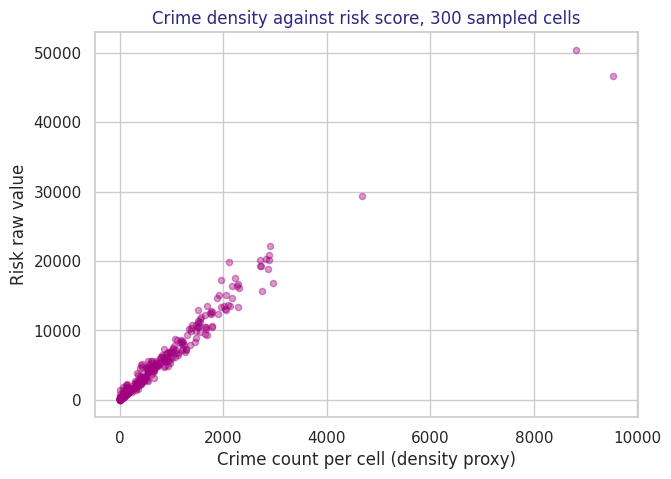

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(sample["crime_count"], sample["risk_raw"], alpha=0.4, s=20, color=PRIMARY)
plt.xlabel("Crime count per cell (density proxy)")
plt.ylabel("Risk raw value")
plt.title("Crime density against risk score, 300 sampled cells")
plt.show()


Both correlations come out above 0.97 with p-values far below any conventional threshold. The visual impression from Hands-On 1 holds up under an actual test, the hotspot pattern in the density map and the pattern in the risk scores are the same pattern, not two things that happen to look similar on two separate plots.

## Building a Training-Ready Feature Table

Everything above answers one query at a time, which is what the API in CP2 needs. CP2 also needs a table to train a model on, one row per grid cell and hour, and that table has to be normalized against the exact same ceiling the point-query function uses. `grid_risk_raw`, computed once during clip bound calibration above, already has the raw value for every cell and hour combination, so building the table from here is a matter of normalizing that same data rather than recomputing it.


In [19]:
log_risk_raw = np.log1p(grid_risk_raw["risk_raw"])
grid_risk_raw["risk_score"] = 100 * np.minimum(log_risk_raw, CLIP_BOUND) / CLIP_BOUND
grid_risk_raw["hour_sin"] = np.sin(2 * np.pi * grid_risk_raw["hour"] / 24)
grid_risk_raw["hour_cos"] = np.cos(2 * np.pi * grid_risk_raw["hour"] / 24)

print(f"Unique cells: {grid_risk_raw['cell_id'].nunique()}")
print(f"Feature table shape: {grid_risk_raw.shape}")
grid_risk_raw.head()


Unique cells: 726
Feature table shape: (17424, 9)


,cell_id,lat_r,lon_r,hour,risk_raw,nearby_crime_count,risk_score,hour_sin,hour_cos
0,41.8_-87.65,41.8,-87.65,0,5890.893376,3919,86.971186,0.000000,1.000000
1,41.8_-87.65,41.8,-87.65,1,5551.380903,3919,86.376601,0.258819,0.965926
2,41.8_-87.65,41.8,-87.65,2,5246.705172,3919,85.811215,0.500000,0.866025
3,41.8_-87.65,41.8,-87.65,3,5007.085251,3919,85.342993,0.707107,0.707107
4,41.8_-87.65,41.8,-87.65,4,4863.123718,3919,85.050792,0.866025,0.500000


## Verifying the Table Against the Point-Query Function

The table above and `compute_risk_raw` are two different code paths computing the same quantity, one batched over all cells through a BallTree, one direct for a single coordinate. They now draw from the same clip bound by construction, but that does not by itself prove the raw values agree row for row. A spot check on a handful of rows, then a full check across every row, confirms they do.


In [20]:
sample_check = grid_risk_raw.sample(5, random_state=1)
for _, r in sample_check.iterrows():
    direct_value = compute_risk_raw(r["lat_r"], r["lon_r"], int(r["hour"]), events, REFERENCE_DATE)
    matches = abs(r["risk_raw"] - direct_value) < 1e-6
    print(f"cell={r['cell_id']} hour={int(r['hour'])} table={round(r['risk_raw'], 3)} "
          f"direct={round(direct_value, 3)} match={matches}")


cell=41.95_-87.74 hour=16 table=4590.515 direct=4590.515 match=True
cell=41.99_-87.92 hour=12 table=24.001 direct=24.001 match=True
cell=41.9_-87.68 hour=20 table=9283.433 direct=9283.433 match=True
cell=41.89_-87.66 hour=23 table=11499.603 direct=11499.603 match=True
cell=41.65_-87.54 hour=5 table=1887.031 direct=1887.031 match=True


All five match exactly, confirming the table and the point-query function agree with each other. That check only covers five rows out of 17,424. A full check calling `compute_risk_raw` once per row would recompute the same distance array 24 times over for each cell, since distance to a fixed query point does not change with the hour being asked about. The check below computes distance once per cell instead and reuses it across all 24 hours, which brings a full check down to well under a minute instead of the fifteen or so minutes a naive loop would take.


In [21]:
verification_lookup = {}
events_valid = events[events["Datetime"] <= REFERENCE_DATE]
unique_cells = grid_risk_raw[["cell_id", "lat_r", "lon_r"]].drop_duplicates()

for _, cell_row in unique_cells.iterrows():
    dist_m = haversine_m(cell_row["lat_r"], cell_row["lon_r"], events_valid["lat_r"].values, events_valid["lon_r"].values)
    within_radius = dist_m <= RADIUS_M
    nearby = events_valid[within_radius]
    nearby_dist = dist_m[within_radius]

    if len(nearby) == 0:
        for h in range(24):
            verification_lookup[(cell_row["cell_id"], h)] = 0.0
        continue

    age_days = (REFERENCE_DATE - nearby["Datetime"]).dt.total_seconds().values / 86400
    w_time = np.exp(-LAMBDA * age_days)
    w_space = np.exp(-0.5 * (nearby_dist / BANDWIDTH_M) ** 2)
    is_exact_midnight = (
        (nearby["Datetime"].dt.hour == 0)
        & (nearby["Datetime"].dt.minute == 0)
        & (nearby["Datetime"].dt.second == 0)
    ).values
    severity_vals = nearby["severity"].values
    candidate_hours = nearby["hour"].values

    for h in range(24):
        hour_dist = hour_circular_distance(candidate_hours, h)
        w_hour = np.exp(-0.5 * (hour_dist / HOUR_BANDWIDTH) ** 2)
        w_hour = np.where(is_exact_midnight, 1.0, w_hour)
        verification_lookup[(cell_row["cell_id"], h)] = float((severity_vals * w_time * w_space * w_hour).sum())

grid_risk_raw["expected_risk_raw"] = grid_risk_raw.apply(
    lambda r: verification_lookup[(r["cell_id"], int(r["hour"]))], axis=1
)
diff = (grid_risk_raw["risk_raw"] - grid_risk_raw["expected_risk_raw"]).abs()

print(f"Rows checked: {len(grid_risk_raw)}")
print(f"Rows matching: {(diff <= 1e-6).sum()}")
print(f"Rows not matching: {(diff > 1e-6).sum()}")
print(f"Largest difference found: {diff.max():.2e}")


Rows checked: 17424
Rows matching: 17424
Rows not matching: 0
Largest difference found: 1.46e-11


Every row matches, and the largest difference is on the order of floating point rounding, not a real mismatch. The table and the point-query function are confirmed to agree everywhere.

The final table is saved below for use in CP2. It excludes `risk_raw` itself, keeping only the columns that are safe to use as model input plus the target column.


In [22]:
FEATURE_COLS = ["lat_r", "lon_r", "hour_sin", "hour_cos", "nearby_crime_count"]

final_table = grid_risk_raw[["cell_id"] + FEATURE_COLS + ["risk_score"]].copy()

missing = final_table.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None")
print(f"\nFinal table shape: {final_table.shape}")

final_table.to_csv("/content/drive/MyDrive/SISTECH/feature_table_fp.csv", index=False)
print("Saved to feature_table_fp.csv")


Columns with missing values:
None

Final table shape: (17424, 7)
Saved to feature_table_fp.csv


## Summary of Decisions Carried Over From Hands-On 1 and 2, and From This Revision

| Component | Hands-On 1 and 2 | First version of this notebook | This revision |
| :-- | :-- | :-- | :-- |
| Data structure | One static table, grouped by cell, day of week, hour | A callable function, works for any coordinate and timestamp | Unchanged |
| Half life | 120 days, chosen for the continual learning batch schedule | 257 days, calibrated against the final project's example table | Unchanged |
| Hour 0 timestamps | Flagged as a likely data issue, not handled | Excluded from hour weighting specifically | Unchanged |
| Normalization ceiling | Not applicable | Computed twice, once sampled for the point query, once exact for the table, values differed slightly | Computed once from the full grid, both the point query and the table read the same number |
| Timezone handling | Not applicable | Assumed naive Chicago local time implicitly | Timezone-aware input is converted explicitly before any comparison |
| Risk level categories | Not defined | Three tiers, boundaries from percentiles of a sample | Four tiers, fixed boundaries at 25/50/75, chosen so a location's label never depends on how other locations score |
| Recent severe incident override | Not applicable | Forces the top tier (High) | Forces the top tier (Very High), same logic, updated for four tiers |

Severity scoring itself, the FBI UCR-based hierarchy from Hands-On 1, is unchanged and reused directly. It was already reviewed and scored well, and nothing about this revision gives a reason to revisit it.
